# Tracking Python API download stats

Pypi download stats is already avaialble here: https://pypistats.org/packages/arcgis

## Get response

In [1]:
import requests
url = 'https://api.anaconda.org/package/esri/arcgis/files'

In [2]:
resp = requests.get(url=url)
downloads = resp.json()

In [3]:
len(downloads)

354

In [4]:
downloads[0]

{'description': None,
 'basename': 'osx-64/arcgis-1.5.0.beta.9-py35_1.tar.bz2',
 'labels': ['beta'],
 'dependencies': {'depends': [{'name': 'ipywidgets', 'specs': [['>=', '7']]},
   {'name': 'keyring', 'specs': []},
   {'name': 'matplotlib', 'specs': []},
   {'name': 'notebook', 'specs': []},
   {'name': 'numpy', 'specs': []},
   {'name': 'pandas', 'specs': []},
   {'name': 'pyshp', 'specs': []},
   {'name': 'python', 'specs': [['>=', '3.5,<3.6.0a0']]},
   {'name': 'six', 'specs': []},
   {'name': 'tornado', 'specs': [['>=', '4.5.3,<5']]},
   {'name': 'widgetsnbextension', 'specs': [['>=', '3']]}]},
 'distribution_type': 'conda',
 'attrs': {'build_number': 1,
  'license': 'Esri Master License Agreement (MLA)',
  'has_prefix': False,
  'machine': 'x86_64',
  'platform': 'osx',
  'depends': ['ipywidgets >=7',
   'keyring',
   'matplotlib',
   'notebook',
   'numpy',
   'pandas',
   'pyshp',
   'python >=3.5,<3.6.0a0',
   'six',
   'tornado >=4.5.3,<5',
   'widgetsnbextension >=3'],
  'bu

## Make a panda dataframe

In [5]:
rows_list = []
for d in downloads:
    os_name  = d['basename'].split('-')[0]
    rows_list.append([d['basename'], os_name, d['version'], d['upload_time'], d['ndownloads']])

In [6]:
import pandas as pd
df = pd.DataFrame(rows_list, columns=['name', 'os', 'version', 'uploaded', 'downloads'])    

Output the downloads to a .CSV file

In [6]:
import os
file_path = os.path.join(".", "conda_download.csv")
df.to_csv(file_path)

Set the datatime index. This is important for time-based plotting.

In [7]:
df['datetime'] = pd.to_datetime(df['uploaded'])
df = df.set_index('datetime') # set time index

In [8]:
df.tail()

,name,os,version,uploaded,downloads
datetime,,,,,
2019-10-04 17:31:40.368000+00:00,win-64/arcgis-1.7.0-py36_805.tar.bz2,win,1.7.0,2019-10-04 17:31:40.368000+00:00,168
2019-10-11 18:42:59.168000+00:00,win-64/arcgis-1.7.0-py36_821.tar.bz2,win,1.7.0,2019-10-11 18:42:59.168000+00:00,21
2019-10-11 16:18:09.345000+00:00,win-64/arcgis-1.7.0-py36_819.tar.bz2,win,1.7.0,2019-10-11 16:18:09.345000+00:00,19
2019-10-15 15:30:05.775000+00:00,win-64/arcgis-1.7.0-py36_834.tar.bz2,win,1.7.0,2019-10-15 15:30:05.775000+00:00,167
2019-10-22 15:32:35.867000+00:00,win-64/arcgis-1.7.0-py36_860.tar.bz2,win,1.7.0,2019-10-22 15:32:35.867000+00:00,191


## How it changes over time

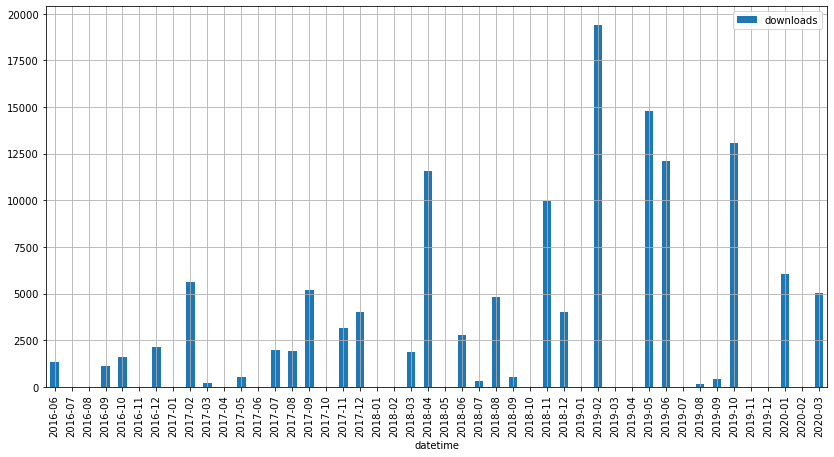

In [9]:
g_time = df.groupby(pd.Grouper(freq="M")).sum() # group by month
ax = g_time.plot(legend=True, kind="bar", figsize=(14,7))

ax.grid(True)
x_labels = g_time.index.strftime('%Y-%m') # year+month
output = ax.set_xticklabels(x_labels)

## By version

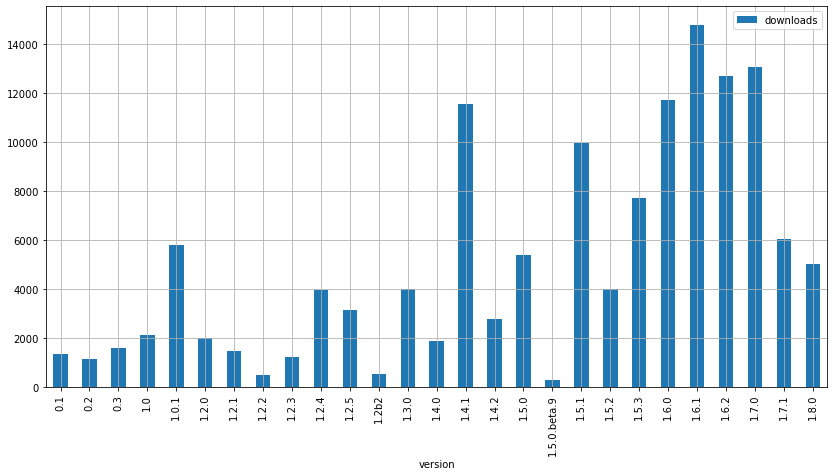

In [10]:
g_version = df.groupby('version')['downloads'].sum() # group by version
g_version.plot(legend=True, kind="bar", figsize=(14,7)).grid(True)

## By OS

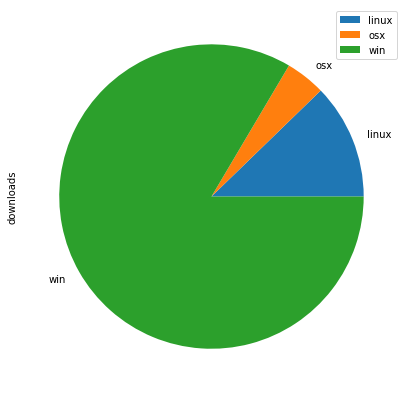

In [11]:
g_os = df.groupby('os')['downloads'].sum()
g_os.plot(legend=True, kind="pie", figsize=(14,7))

## Plot for a specific time point/interval

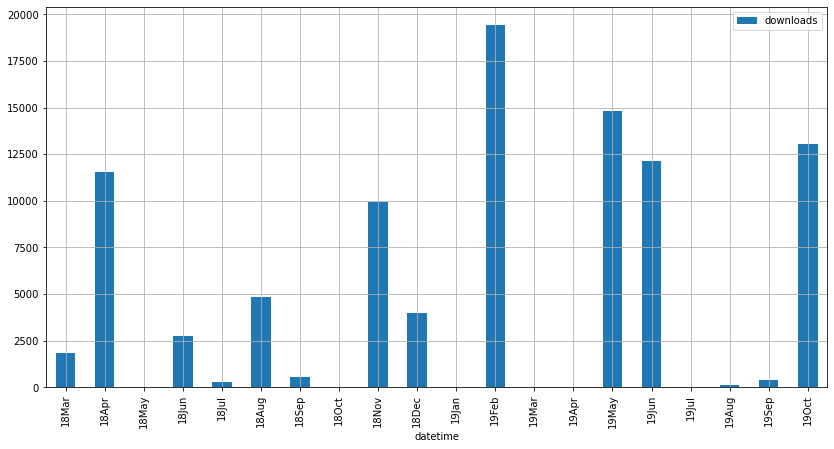

In [12]:
g_time_1 = df['2018':'2019'].groupby(pd.Grouper(freq="M"))['downloads'].sum() # group by month
ax = g_time_1.plot(legend=True, kind="bar", figsize=(14,7))

ax.grid(True)
x_labels_2 = g_time_1.index.strftime('%y%b') # year+month
output_2 = ax.set_xticklabels(x_labels_2)